In [17]:
import itertools
import warnings
from typing import Any

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from skforecast.recursive import ForecasterRecursiveMultiSeries

from timelens import ConditionalPermutationImportance, ManualPartitioner, TreePartitioner
from timelens.adapters.skforecast import from_skforecast
from timelens.visualization import plot_importance_bar, plot_importance_heatmap

warnings.filterwarnings("ignore")
np.random.seed(42)

In [18]:
from pathlib import Path

data_path = Path("./data/competitive_products_dataset_with_ground_truth_multipliers.csv")
data = pd.read_csv(data_path, parse_dates=["date"])
data = data.set_index("date").asfreq("D")

# Select only the features of interest
features_of_interest = ["product_a_demand", "product_b_demand", "product_c_demand", "promo_a", "promo_b", "weekend"]
data = data[features_of_interest]

print(f"Data shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nData info:")
print(data.info())
print(f"\nCorrelation matrix:")
print(data.corr())
print(f"\nFirst few rows:")
data.head(10)

Data shape: (1820, 6)
Date range: 2022-01-01 00:00:00 to 2026-12-25 00:00:00

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1820 entries, 2022-01-01 to 2026-12-25
Freq: D
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_a_demand  1820 non-null   float64
 1   product_b_demand  1820 non-null   float64
 2   product_c_demand  1820 non-null   float64
 3   promo_a           1820 non-null   float64
 4   promo_b           1820 non-null   float64
 5   weekend           1820 non-null   float64
dtypes: float64(6)
memory usage: 99.5 KB
None

Correlation matrix:
                  product_a_demand  product_b_demand  product_c_demand  \
product_a_demand          1.000000         -0.716555          0.345242   
product_b_demand         -0.716555          1.000000          0.336511   
product_c_demand          0.345242          0.336511          1.000000   
promo_a                   0.672084      

,product_a_demand,product_b_demand,product_c_demand,promo_a,promo_b,weekend
date,,,,,,
2022-01-01,227.158496,279.283684,251.911200,0.0,0.0,1.0
2022-01-02,228.713259,266.710459,259.282292,0.0,0.0,1.0
2022-01-03,193.679802,235.503441,223.052068,0.0,0.0,0.0
2022-01-04,192.528990,230.356281,212.509610,0.0,0.0,0.0
2022-01-05,199.719054,233.769426,231.454447,0.0,0.0,0.0
2022-01-06,193.974623,232.081230,219.409742,0.0,0.0,0.0
2022-01-07,199.223529,234.275441,224.852245,0.0,0.0,0.0
2022-01-08,166.278075,352.648864,245.155496,0.0,1.0,1.0
2022-01-09,145.099545,378.876551,249.812313,0.0,1.0,1.0


## 2. Data Visualization and Exploratory Analysis

Visualize the three product demand time series and feature patterns.

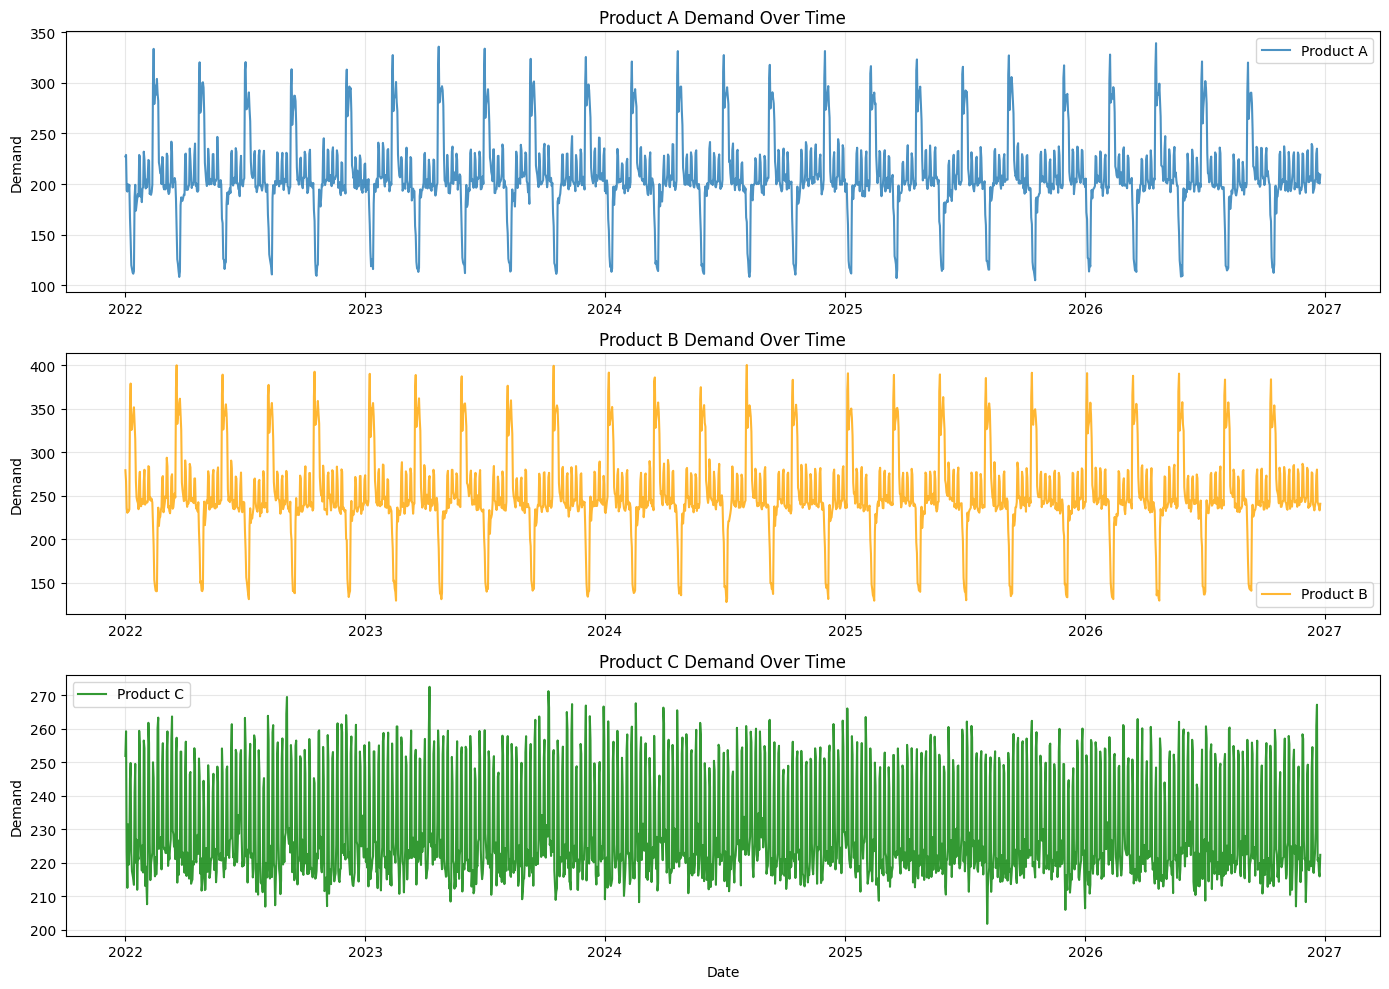

Summary statistics by product:
       product_a_demand  product_b_demand  product_c_demand
count       1820.000000       1820.000000       1820.000000
mean         208.931004        251.810219        229.380210
std           40.109751         48.028126         15.763751
min          105.040838        127.816605        201.747623
25%          195.310229        235.562482        218.025498
50%          202.299561        242.569025        222.251048
75%          226.534324        273.096647        246.396888
max          338.969623        400.184905        272.573442


In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot product demand time series
axes[0].plot(data.index, data["product_a_demand"], label="Product A", linewidth=1.5, alpha=0.8)
axes[0].set_title("Product A Demand Over Time")
axes[0].set_ylabel("Demand")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(data.index, data["product_b_demand"], label="Product B", color="orange", linewidth=1.5, alpha=0.8)
axes[1].set_title("Product B Demand Over Time")
axes[1].set_ylabel("Demand")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(data.index, data["product_c_demand"], label="Product C", color="green", linewidth=1.5, alpha=0.8)
axes[2].set_title("Product C Demand Over Time")
axes[2].set_ylabel("Demand")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("Summary statistics by product:")
print(data[["product_a_demand", "product_b_demand", "product_c_demand"]].describe())

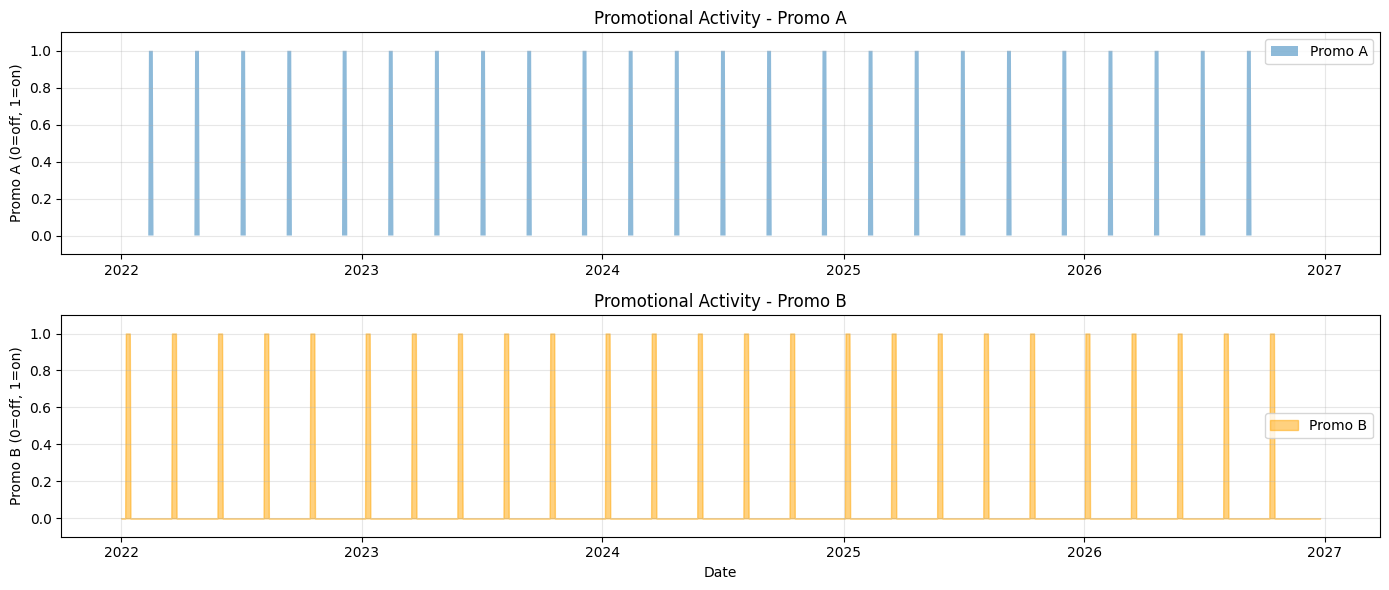


Weekend indicator usage: 520.0 weekend days out of 1820 total days
Percentage of weekends: 28.6%


In [20]:
# Visualize promotional features
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].fill_between(data.index, data["promo_a"], alpha=0.5, label="Promo A")
axes[0].set_title("Promotional Activity - Promo A")
axes[0].set_ylabel("Promo A (0=off, 1=on)")
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].fill_between(data.index, data["promo_b"], alpha=0.5, color="orange", label="Promo B")
axes[1].set_title("Promotional Activity - Promo B")
axes[1].set_ylabel("Promo B (0=off, 1=on)")
axes[1].set_ylim(-0.1, 1.1)
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Weekend indicator
print(f"\nWeekend indicator usage: {data['weekend'].sum()} weekend days out of {len(data)} total days")
print(f"Percentage of weekends: {data['weekend'].mean() * 100:.1f}%")

## 3. Model Training

Train a `ForecasterRecursiveMultiSeries` model using LightGBM to forecast all three product demands simultaneously.

In [21]:
# Prepare data for skforecast (pivot to wide format)
# Targets: product_a_demand, product_b_demand, product_c_demand (as separate series)
targets = ["product_a_demand", "product_b_demand", "product_c_demand"]
exog_features = ["promo_a", "promo_b", "weekend"]

# Create series DataFrame (wide format: each product is a column)
series_wide = data[targets].copy()

# Create exogenous features dict (same features for all series, but replicated for skforecast format)
# In this case, we'll treat it as if we have the same exog for all products
exog_dict = {
    "product_a_demand": data[exog_features],
    "product_b_demand": data[exog_features],
    "product_c_demand": data[exog_features],
}

print(f"Series shape: {series_wide.shape}")
print(f"Series columns: {list(series_wide.columns)}")
print(f"Exogenous features: {exog_features}")
print(f"Index frequency: {series_wide.index.freq}")
series_wide.head()

Series shape: (1820, 3)
Series columns: ['product_a_demand', 'product_b_demand', 'product_c_demand']
Exogenous features: ['promo_a', 'promo_b', 'weekend']
Index frequency: <Day>


,product_a_demand,product_b_demand,product_c_demand
date,,,
2022-01-01,227.158496,279.283684,251.911200
2022-01-02,228.713259,266.710459,259.282292
2022-01-03,193.679802,235.503441,223.052068
2022-01-04,192.528990,230.356281,212.509610
2022-01-05,199.719054,233.769426,231.454447


In [22]:
# Train the global forecasting model
forecaster = ForecasterRecursiveMultiSeries(
    regressor=lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1,
    ),
    lags=5,  # Use lags 1-5 to capture temporal dependencies
    encoding="ordinal",
)

forecaster.fit(series=series_wide, exog=exog_dict, suppress_warnings=True)
print("Model trained successfully!")
print(f"Series in model: {forecaster.series_names_in_}")
print(f"Lags used: {forecaster.lags}")

Model trained successfully!
Series in model: ['product_a_demand', 'product_b_demand', 'product_c_demand']
Lags used: [1 2 3 4 5]


In [23]:
# Create timelens adapter and extract training data
adapter = from_skforecast(forecaster, series=series_wide, exog=exog_dict)
X, y = adapter.get_training_data()

print(f"Training matrix X shape: {X.shape}")
print(f"Target y shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"Series column: {adapter.get_series_column()}")
X.head(10)

Training matrix X shape: (5445, 9)
Target y shape: (5445,)

Feature columns: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', '_level_skforecast', 'promo_a', 'promo_b', 'weekend']
Series column: _level_skforecast


,lag_1,lag_2,lag_3,lag_4,lag_5,_level_skforecast,promo_a,promo_b,weekend
2022-01-06,199.719054,192.528990,193.679802,228.713259,227.158496,0,0.0,0.0,0.0
2022-01-07,193.974623,199.719054,192.528990,193.679802,228.713259,0,0.0,0.0,0.0
2022-01-08,199.223529,193.974623,199.719054,192.528990,193.679802,0,0.0,1.0,1.0
2022-01-09,166.278075,199.223529,193.974623,199.719054,192.528990,0,0.0,1.0,1.0
2022-01-10,145.099545,166.278075,199.223529,193.974623,199.719054,0,0.0,1.0,0.0
2022-01-11,119.830029,145.099545,166.278075,199.223529,193.974623,0,0.0,1.0,0.0
2022-01-12,116.523369,119.830029,145.099545,166.278075,199.223529,0,0.0,1.0,0.0
2022-01-13,112.697573,116.523369,119.830029,145.099545,166.278075,0,0.0,1.0,0.0
2022-01-14,111.494414,112.697573,116.523369,119.830029,145.099545,0,0.0,1.0,0.0
2022-01-15,113.866354,111.494414,112.697573,116.523369,119.830029,0,0.0,0.0,1.0


## 4. Feature Importance Methods Comparison

We apply four different feature importance methods to the trained model and compare their rankings:

1. **Standard Global Permutation Feature Importance (PFI)** - Shuffles features globally
2. **LightGBM Gain Importance** - Tree-based importance from ensemble
3. **Manual Conditional Subgroup cs-PFI** - User-defined groups by product
4. **Automated Tree-based cs-PFI** - Automatically discovered subgroups

In [24]:
# Define features of interest (all exogenous features + lagged target features)
feature_cols = list(X.columns)
# Filter out the series identifier column
features_of_interest = [col for col in feature_cols if col != adapter.get_series_column()]

print(f"Features of interest: {features_of_interest}")

# Standard Global PFI using sklearn
pfi_result = permutation_importance(
    forecaster.regressor,
    X,
    y.values,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
)

# Create DataFrame with results
standard_pfi = pd.DataFrame({
    "feature": X.columns,
    "importance": pfi_result.importances_mean,
    "std": pfi_result.importances_std,
}).sort_values("importance", ascending=False)

# Filter to features of interest
standard_pfi_filtered = standard_pfi[standard_pfi["feature"].isin(features_of_interest)].copy()

print("\nStandard Global PFI Results:")
standard_pfi_filtered

Features of interest: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'promo_a', 'promo_b', 'weekend']



Standard Global PFI Results:


,feature,importance,std
0,lag_1,1882.952828,27.088237
8,weekend,561.767726,9.101499
7,promo_b,228.317837,5.571836
1,lag_2,159.926941,5.578863
6,promo_a,153.857429,4.718774
2,lag_3,57.214261,1.782269
3,lag_4,6.925797,0.363092
4,lag_5,4.912342,0.157186


In [25]:
# Extract LightGBM Gain importance from the fitted regressor
lgbm_feature_names = forecaster.regressor.feature_name_
lgbm_importances = forecaster.regressor.feature_importances_

gain_importance = pd.DataFrame({
    "feature": lgbm_feature_names,
    "importance": lgbm_importances,
}).sort_values("importance", ascending=False)

# Filter to features of interest
gain_importance_filtered = gain_importance[
    gain_importance["feature"].isin(features_of_interest)
].copy()

print("LightGBM Gain Importance Results:")
gain_importance_filtered

LightGBM Gain Importance Results:


,feature,importance
0,lag_1,653
1,lag_2,413
2,lag_3,376
4,lag_5,323
3,lag_4,303
6,promo_a,142
8,weekend,137
7,promo_b,127


In [26]:
# Define manual groups based on domain knowledge: group by product
# In skforecast 0.21+, series are ordinal-encoded (0, 1, 2, ...)
series_names = forecaster.series_names_in_
manual_mapping = {
    i: targets[i]  # Map each series to its product name
    for i in range(len(series_names))
}

print(f"Manual grouping by product: {manual_mapping}")

# Create ManualPartitioner
manual_partitioner = ManualPartitioner(
    mapping=manual_mapping,
    series_col=adapter.get_series_column(),
)

# Compute Manual cs-PFI using timelens
manual_cspfi_explainer = ConditionalPermutationImportance(
    model=adapter,
    metric="mse",
    strategy="manual",
    partitioner=manual_partitioner,
    n_repeats=10,
    random_state=42,
)

manual_cspfi_result = manual_cspfi_explainer.compute(X, y, features=features_of_interest)

print("\nManual cs-PFI Results (grouped by product):")
manual_cspfi_result.to_dataframe()

Manual grouping by product: {0: 'product_a_demand', 1: 'product_b_demand', 2: 'product_c_demand'}

Manual cs-PFI Results (grouped by product):


,feature,importance,std
0,lag_1,1489.182238,51.684188
7,weekend,567.350902,11.460486
6,promo_b,234.791769,10.409084
5,promo_a,154.750503,4.421069
1,lag_2,106.329870,4.758885
2,lag_3,51.433876,3.740571
3,lag_4,5.127354,0.318621
4,lag_5,4.815258,0.265696


In [27]:
 # Create TreePartitioner for automated subgroup discovery
tree_partitioner = TreePartitioner(
    max_depth=4,
    min_samples_leaf=0.05,
    series_col=adapter.get_series_column(),
    random_state=42,
)

# Compute Automated cs-PFI using timelens
auto_cspfi_explainer = ConditionalPermutationImportance(
    model=adapter,
    metric="mse",
    strategy="auto",
    partitioner=tree_partitioner,
    n_repeats=10,
    random_state=42,
)

auto_cspfi_result = auto_cspfi_explainer.compute(X, y, features=features_of_interest)

print("Automated Tree-based cs-PFI Results:")
auto_cspfi_result.to_dataframe()

Automated Tree-based cs-PFI Results:


,feature,importance,std
7,weekend,390.260084,11.330901
0,lag_1,379.734136,12.513667
6,promo_b,206.575160,8.304163
5,promo_a,136.179245,3.762462
1,lag_2,96.549761,5.807067
2,lag_3,19.973201,1.594958
3,lag_4,3.757013,0.241173
4,lag_5,3.100164,0.164439


## 5. Stability Analysis

Assess the consistency of feature importance methods across multiple samples from the test period.
We create rolling windows of data to simulate different evaluation scenarios.

In [28]:
def create_rolling_window_sample(
    data: pd.DataFrame,
    targets: list,
    exog_features: list,
    window_size: int = 100,
    offset: int = 0,
) -> tuple[pd.DataFrame, dict]:
    """
    Create a rolling window sample for stability testing.
    
    Args:
        data: Full dataset with targets and exogenous features
        targets: Target column names
        exog_features: Exogenous feature column names
        window_size: Size of the rolling window
        offset: Number of samples to skip from the end
        
    Returns:
        Tuple of (series_wide, exog_dict)
    """
    # Select the window
    end_idx = len(data) - offset
    start_idx = max(0, end_idx - window_size)
    window_data = data.iloc[start_idx:end_idx].copy()
    
    # Create series DataFrame (wide format)
    series_wide = window_data[targets].copy()
    
    # Create exogenous features dict
    exog_dict = {
        target: window_data[exog_features]
        for target in targets
    }
    
    return series_wide, exog_dict


def calculate_stability_score(rankings: list[pd.Series]) -> float:
    """
    Calculate the stability score as average pairwise Spearman correlation.
    
    Args:
        rankings: List of pandas Series, each containing feature importance scores.
        
    Returns:
        Average pairwise Spearman correlation (stability score).
    """
    if len(rankings) < 2:
        return 1.0

    all_correlations = []
    for rank1, rank2 in itertools.combinations(rankings, 2):
        # Align by feature names
        aligned_rank1, aligned_rank2 = rank1.align(rank2, join="inner")
        if len(aligned_rank1) > 1:
            correlation, _ = spearmanr(aligned_rank1, aligned_rank2)
            if not np.isnan(correlation):
                all_correlations.append(correlation)

    return np.mean(all_correlations) if all_correlations else 0.0

In [29]:
# Run stability analysis with rolling windows
N_WINDOWS = 5  # Number of rolling windows
WINDOW_SIZE = 200  # Size of each window

# Storage for rankings from each window
standard_pfi_rankings = []
manual_cspfi_rankings = []
auto_cspfi_rankings = []

print(f"Running stability analysis with {N_WINDOWS} rolling windows (size={WINDOW_SIZE})...")
print("-" * 70)

for i in range(N_WINDOWS):
    print(f"Window {i + 1}/{N_WINDOWS}...", end=" ")

    # Create rolling window sample
    window_series_wide, window_exog_dict = create_rolling_window_sample(
        data,
        targets=targets,
        exog_features=exog_features,
        window_size=WINDOW_SIZE,
        offset=i * 50,  # Slide by 50 samples
    )

    # Train model on window sample
    window_forecaster = ForecasterRecursiveMultiSeries(
        regressor=lgb.LGBMRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            verbose=-1,
        ),
        lags=5,
        encoding="ordinal",
    )
    window_forecaster.fit(
        series=window_series_wide,
        exog=window_exog_dict,
        suppress_warnings=True,
    )

    # Create adapter and get training data
    window_adapter = from_skforecast(
        window_forecaster,
        series=window_series_wide,
        exog=window_exog_dict,
    )
    X_window, y_window = window_adapter.get_training_data()

    # Compute Standard PFI
    window_pfi_result = permutation_importance(
        window_forecaster.regressor,
        X_window.values,
        y_window.values,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
        scoring="neg_mean_squared_error",
    )
    window_pfi_series = pd.Series(
        window_pfi_result.importances_mean,
        index=X_window.columns,
    )
    # Filter to features of interest
    window_pfi_series_filtered = window_pfi_series[
        window_pfi_series.index.isin(features_of_interest)
    ]
    standard_pfi_rankings.append(window_pfi_series_filtered)

    # Compute Manual cs-PFI
    window_manual_partitioner = ManualPartitioner(
        mapping=manual_mapping,
        series_col=window_adapter.get_series_column(),
    )
    window_manual_cspfi = ConditionalPermutationImportance(
        model=window_adapter,
        metric="mse",
        strategy="manual",
        partitioner=window_manual_partitioner,
        n_repeats=5,
        random_state=42,
    )
    window_manual_result = window_manual_cspfi.compute(
        X_window, y_window, features=features_of_interest
    )
    window_manual_series = pd.Series(
        window_manual_result.importances,
        index=window_manual_result.feature_names,
    )
    manual_cspfi_rankings.append(window_manual_series)

    # Compute Auto cs-PFI
    window_tree_partitioner = TreePartitioner(
        max_depth=4,
        min_samples_leaf=0.05,
        series_col=window_adapter.get_series_column(),
        random_state=42,
    )
    window_auto_cspfi = ConditionalPermutationImportance(
        model=window_adapter,
        metric="mse",
        strategy="auto",
        partitioner=window_tree_partitioner,
        n_repeats=5,
        random_state=42,
    )
    window_auto_result = window_auto_cspfi.compute(
        X_window, y_window, features=features_of_interest
    )
    window_auto_series = pd.Series(
        window_auto_result.importances,
        index=window_auto_result.feature_names,
    )
    auto_cspfi_rankings.append(window_auto_series)

    print("Done")

print("-" * 70)
print("Stability analysis complete!")

Running stability analysis with 5 rolling windows (size=200)...
----------------------------------------------------------------------
Window 1/5... Done
Window 2/5... Done
Window 3/5... Done
Window 4/5... Done
Window 5/5... Done
----------------------------------------------------------------------
Stability analysis complete!


In [30]:
# Calculate stability scores
standard_pfi_stability = calculate_stability_score(standard_pfi_rankings)
manual_cspfi_stability = calculate_stability_score(manual_cspfi_rankings)
auto_cspfi_stability = calculate_stability_score(auto_cspfi_rankings)

stability_results = pd.DataFrame([
    {"Method": "Standard PFI", "Stability Score": f"{standard_pfi_stability:.4f}"},
    {"Method": "Manual cs-PFI (by product)", "Stability Score": f"{manual_cspfi_stability:.4f}"},
    {"Method": "Auto cs-PFI", "Stability Score": f"{auto_cspfi_stability:.4f}"},
])

print("Stability Analysis Results:\n")
print(f"Standard PFI Stability:      {standard_pfi_stability:.4f}")
print(f"Manual cs-PFI Stability:     {manual_cspfi_stability:.4f}")
print(f"Auto cs-PFI Stability:       {auto_cspfi_stability:.4f}")
print()
stability_results

Stability Analysis Results:

Standard PFI Stability:      0.8833
Manual cs-PFI Stability:     0.8929
Auto cs-PFI Stability:       0.8524



,Method,Stability Score
0,Standard PFI,0.8833
1,Manual cs-PFI (by product),0.8929
2,Auto cs-PFI,0.8524


## 6. Results Visualization

Visualize and compare the feature importance results from different methods.

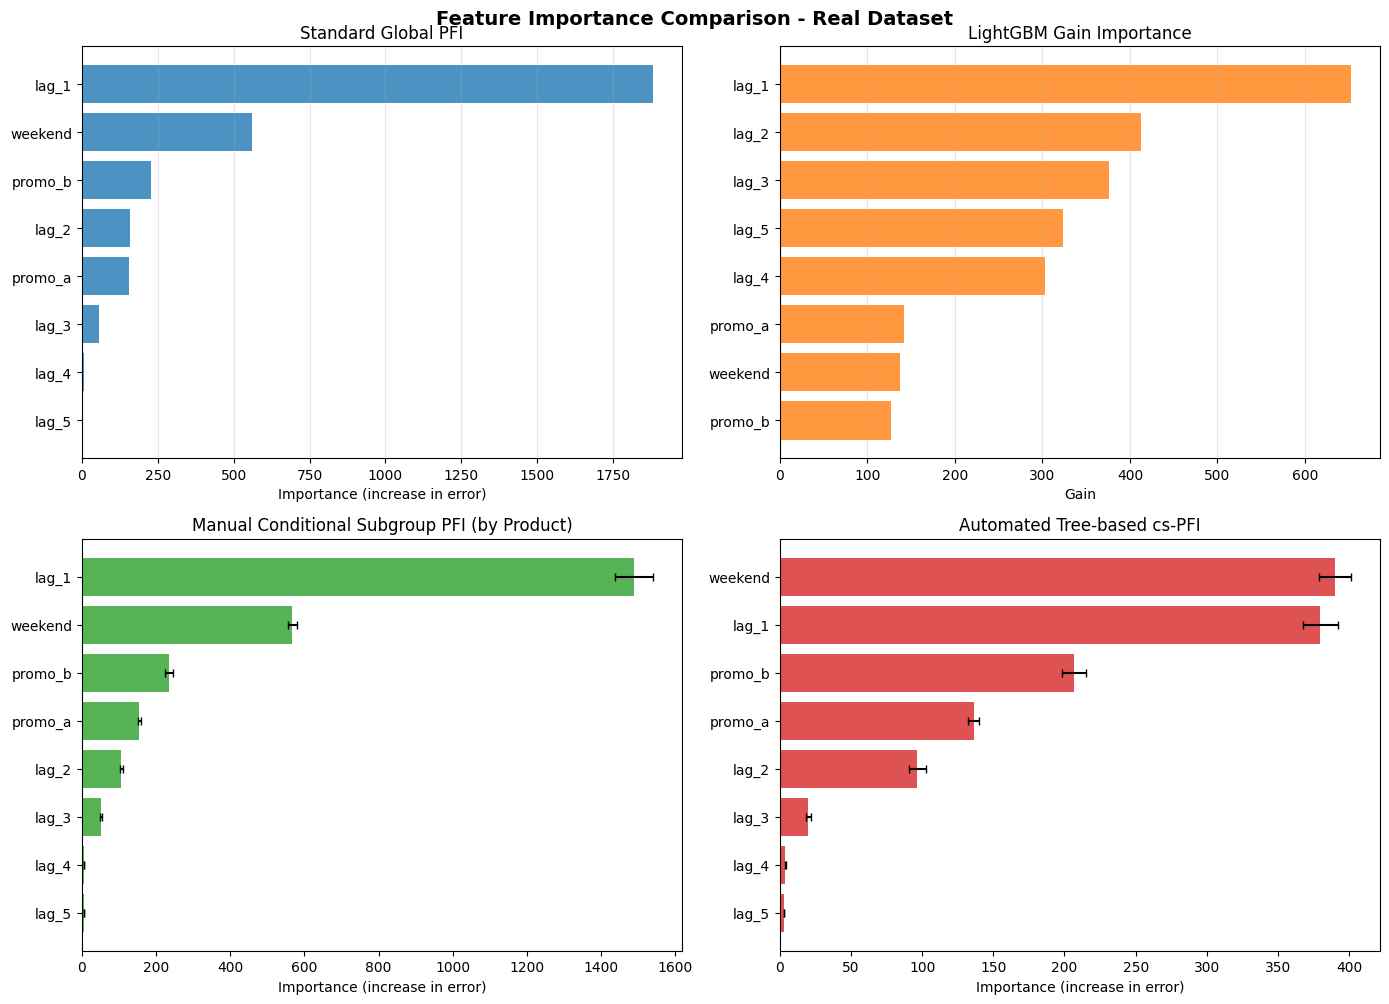

In [31]:
# Compare importance rankings side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Standard PFI
axes[0, 0].clear()
std_pfi_sorted = standard_pfi_filtered.sort_values("importance", ascending=True)
axes[0, 0].barh(std_pfi_sorted["feature"], std_pfi_sorted["importance"], color="#1f77b4", alpha=0.8)
axes[0, 0].set_xlabel("Importance (increase in error)")
axes[0, 0].set_title("Standard Global PFI")
axes[0, 0].grid(True, alpha=0.3, axis='x')

# LGBM Gain
axes[0, 1].clear()
gain_sorted = gain_importance_filtered.sort_values("importance", ascending=True)
axes[0, 1].barh(gain_sorted["feature"], gain_sorted["importance"], color="#ff7f0e", alpha=0.8)
axes[0, 1].set_xlabel("Gain")
axes[0, 1].set_title("LightGBM Gain Importance")
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Manual cs-PFI
plot_importance_bar(
    manual_cspfi_result,
    ax=axes[1, 0],
    title="Manual Conditional Subgroup PFI (by Product)",
    color="#2ca02c",
    max_features=10,
)

# Auto cs-PFI
plot_importance_bar(
    auto_cspfi_result,
    ax=axes[1, 1],
    title="Automated Tree-based cs-PFI",
    color="#d62728",
    max_features=10,
)

plt.tight_layout()
plt.suptitle("Feature Importance Comparison - Real Dataset", y=1.00, fontsize=14, fontweight='bold')
plt.show()

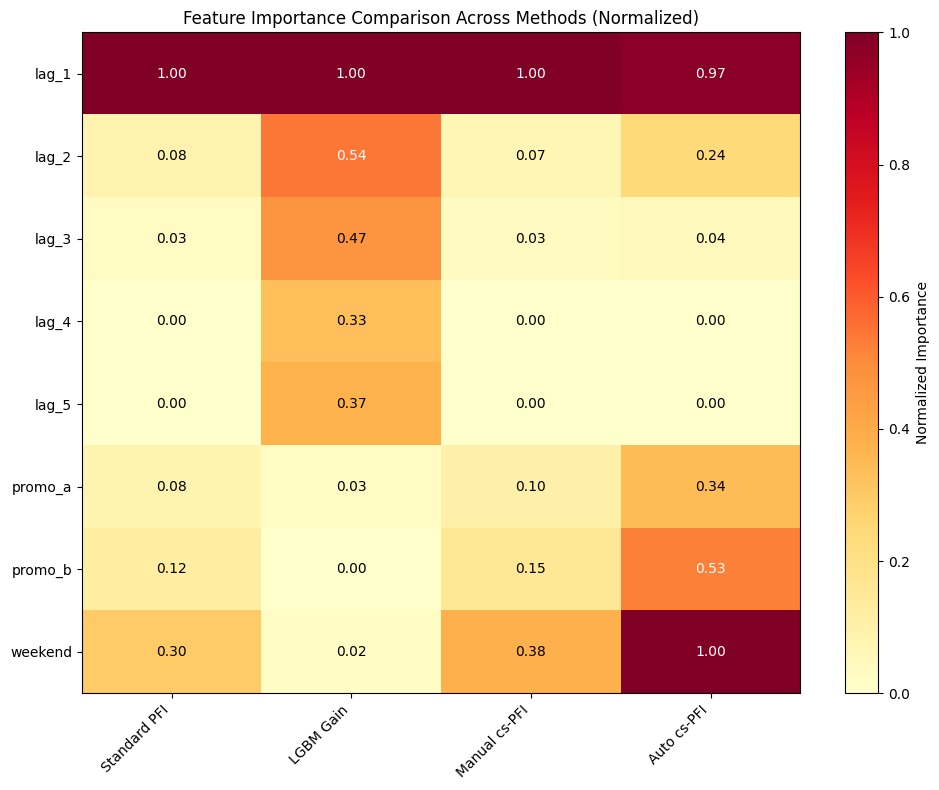

In [32]:
# Create heatmap comparing all methods (normalized importances)
def normalize_series(s):
    if s.max() - s.min() == 0:
        return s
    return (s - s.min()) / (s.max() - s.min())


# Create comparison DataFrame
comparison_data = {
    "Standard PFI": normalize_series(standard_pfi_filtered.set_index("feature")["importance"]),
    "LGBM Gain": normalize_series(gain_importance_filtered.set_index("feature")["importance"]),
    "Manual cs-PFI": normalize_series(manual_cspfi_result.to_dataframe().set_index("feature")["importance"]),
    "Auto cs-PFI": normalize_series(auto_cspfi_result.to_dataframe().set_index("feature")["importance"]),
}

comparison_df = pd.DataFrame(comparison_data)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(comparison_df.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(np.arange(len(comparison_df.columns)))
ax.set_yticks(np.arange(len(comparison_df.index)))
ax.set_xticklabels(comparison_df.columns, rotation=45, ha="right")
ax.set_yticklabels(comparison_df.index)

# Annotate cells
for i in range(len(comparison_df.index)):
    for j in range(len(comparison_df.columns)):
        value = comparison_df.iloc[i, j]
        text_color = "white" if value > 0.5 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=10)

fig.colorbar(im, ax=ax, label="Normalized Importance")
ax.set_title("Feature Importance Comparison Across Methods (Normalized)")
plt.tight_layout()
plt.show()

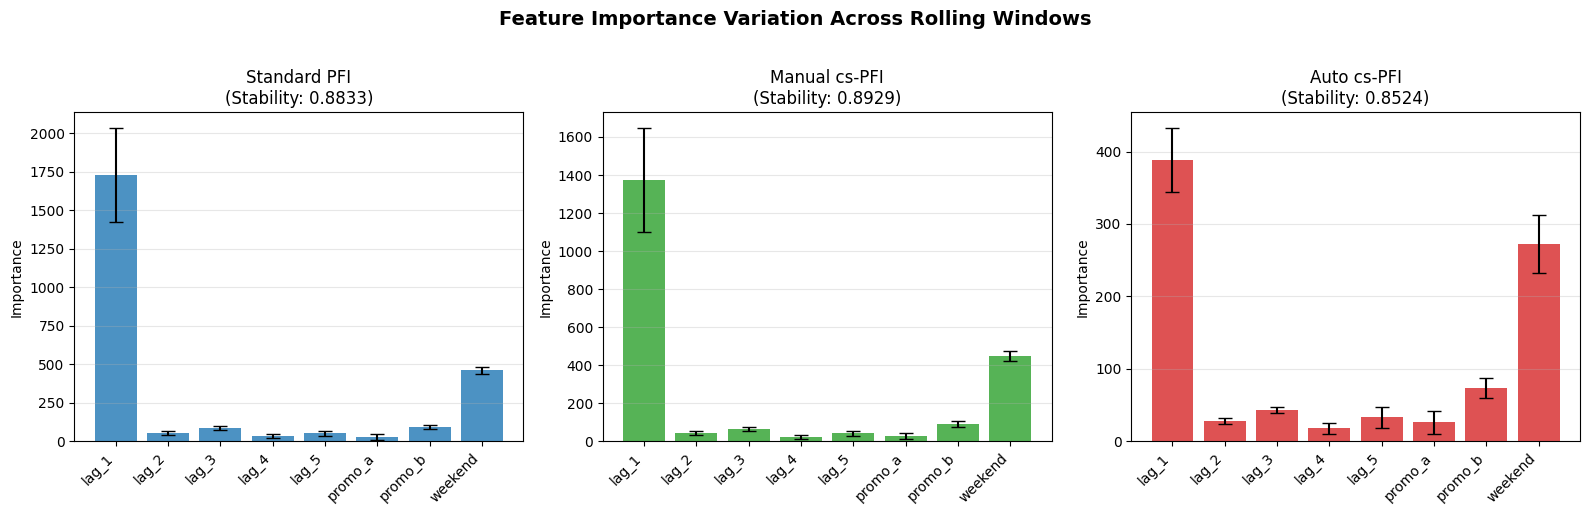

In [33]:
# Visualize stability: feature importance variation across rolling windows
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Standard PFI variation
pfi_df_list = [r.to_frame().T for r in standard_pfi_rankings]
pfi_combined = pd.concat(pfi_df_list, ignore_index=True)
pfi_means = pfi_combined.mean()
pfi_stds = pfi_combined.std()

axes[0].bar(range(len(pfi_means)), pfi_means.values, yerr=pfi_stds.values, capsize=5, color="#1f77b4", alpha=0.8)
axes[0].set_xticks(range(len(pfi_means)))
axes[0].set_xticklabels(pfi_means.index, rotation=45, ha="right")
axes[0].set_ylabel("Importance")
axes[0].set_title(f"Standard PFI\n(Stability: {standard_pfi_stability:.4f})")
axes[0].grid(True, alpha=0.3, axis='y')

# Manual cs-PFI variation
manual_df_list = [r.to_frame().T for r in manual_cspfi_rankings]
manual_combined = pd.concat(manual_df_list, ignore_index=True)
manual_means = manual_combined.mean()
manual_stds = manual_combined.std()

axes[1].bar(range(len(manual_means)), manual_means.values, yerr=manual_stds.values, capsize=5, color="#2ca02c", alpha=0.8)
axes[1].set_xticks(range(len(manual_means)))
axes[1].set_xticklabels(manual_means.index, rotation=45, ha="right")
axes[1].set_ylabel("Importance")
axes[1].set_title(f"Manual cs-PFI\n(Stability: {manual_cspfi_stability:.4f})")
axes[1].grid(True, alpha=0.3, axis='y')

# Auto cs-PFI variation
auto_df_list = [r.to_frame().T for r in auto_cspfi_rankings]
auto_combined = pd.concat(auto_df_list, ignore_index=True)
auto_means = auto_combined.mean()
auto_stds = auto_combined.std()

axes[2].bar(range(len(auto_means)), auto_means.values, yerr=auto_stds.values, capsize=5, color="#d62728", alpha=0.8)
axes[2].set_xticks(range(len(auto_means)))
axes[2].set_xticklabels(auto_means.index, rotation=45, ha="right")
axes[2].set_ylabel("Importance")
axes[2].set_title(f"Auto cs-PFI\n(Stability: {auto_cspfi_stability:.4f})")
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("Feature Importance Variation Across Rolling Windows", y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Conclusions and Key Insights

Analysis of feature importance methods on real competitive products demand dataset.

In [34]:
# Create comprehensive summary table
summary_data = []

# Add methods to summary
summary_data.append({
    "Method": "Standard PFI",
    "Approach": "Global permutation across all data",
    "Stability Score": f"{standard_pfi_stability:.4f}",
    "Key Advantage": "Simple baseline",
    "Key Limitation": "Breaks correlation structure"
})

summary_data.append({
    "Method": "LGBM Gain",
    "Approach": "Tree-based split importance",
    "Stability Score": "N/A",
    "Key Advantage": "Model interpretable",
    "Key Limitation": "Only tree-based models"
})

summary_data.append({
    "Method": "Manual cs-PFI",
    "Approach": f"Domain-based groups ({len(set(manual_mapping.values()))} products)",
    "Stability Score": f"{manual_cspfi_stability:.4f}",
    "Key Advantage": "Preserves known structure",
    "Key Limitation": "Requires domain knowledge"
})

summary_data.append({
    "Method": "Auto cs-PFI",
    "Approach": "Automatically discovered subgroups",
    "Stability Score": f"{auto_cspfi_stability:.4f}",
    "Key Advantage": "Discovers optimal structure",
    "Key Limitation": "More computationally intensive"
})

summary_df = pd.DataFrame(summary_data)
print("=" * 100)
print("EXPERIMENT RESULTS SUMMARY - REAL COMPETITIVE PRODUCTS DATASET")
print("=" * 100)
print(f"\nDataset: {len(data)} time periods, {len(targets)} product series")
print(f"Features: {len(exog_features)} exogenous features + {len(forecaster.lags)} lagged features")
print(f"Stability windows: {N_WINDOWS} rolling windows of size {WINDOW_SIZE}")
print()
print(summary_df.to_string(index=False))
print()
print("=" * 100)

EXPERIMENT RESULTS SUMMARY - REAL COMPETITIVE PRODUCTS DATASET

Dataset: 1820 time periods, 3 product series
Features: 3 exogenous features + 5 lagged features
Stability windows: 5 rolling windows of size 200

       Method                           Approach Stability Score               Key Advantage                 Key Limitation
 Standard PFI Global permutation across all data          0.8833             Simple baseline   Breaks correlation structure
    LGBM Gain        Tree-based split importance             N/A         Model interpretable         Only tree-based models
Manual cs-PFI   Domain-based groups (3 products)          0.8929   Preserves known structure      Requires domain knowledge
  Auto cs-PFI Automatically discovered subgroups          0.8524 Discovers optimal structure More computationally intensive



In [35]:
# Detailed observations
print("\nKEY FINDINGS:\n")

print("1. FEATURE IMPORTANCE RANKINGS:")
print(f"   - Standard PFI top features: {', '.join(standard_pfi_filtered.head(3)['feature'].values)}")
print(f"   - LGBM Gain top features: {', '.join(gain_importance_filtered.head(3)['feature'].values)}")
manual_top = manual_cspfi_result.to_dataframe().sort_values('importance', ascending=False).head(3)
print(f"   - Manual cs-PFI top features: {', '.join(manual_top['feature'].values)}")
auto_top = auto_cspfi_result.to_dataframe().sort_values('importance', ascending=False).head(3)
print(f"   - Auto cs-PFI top features: {', '.join(auto_top['feature'].values)}")

print("\n2. STABILITY COMPARISON:")
if manual_cspfi_stability > standard_pfi_stability:
    improvement = ((manual_cspfi_stability - standard_pfi_stability) / standard_pfi_stability * 100)
    print(f"   - Manual cs-PFI is {improvement:.1f}% more stable than Standard PFI")
else:
    print(f"   - Manual cs-PFI and Standard PFI show similar stability")

if auto_cspfi_stability > standard_pfi_stability:
    improvement = ((auto_cspfi_stability - standard_pfi_stability) / standard_pfi_stability * 100)
    print(f"   - Auto cs-PFI is {improvement:.1f}% more stable than Standard PFI")
else:
    print(f"   - Auto cs-PFI and Standard PFI show similar stability")

print("\n3. BUSINESS INTERPRETATION:")
print("   Expected feature importance order for competitive products:")
print("   - promo_a, promo_b: HIGH impact (directly drive demand)")
print("   - weekend: MODERATE impact (seasonality pattern)")
print("   - lagged targets: HIGH impact (temporal autocorrelation)")

print("\n4. METHOD RECOMMENDATIONS:")
print("   - Use Manual cs-PFI: When product structure is known and stable")
print("   - Use Auto cs-PFI: When discovering unknown product interactions/correlations")
print("   - Use Standard PFI: For baseline comparison and simple models")


KEY FINDINGS:

1. FEATURE IMPORTANCE RANKINGS:
   - Standard PFI top features: lag_1, weekend, promo_b
   - LGBM Gain top features: lag_1, lag_2, lag_3
   - Manual cs-PFI top features: lag_1, weekend, promo_b
   - Auto cs-PFI top features: weekend, lag_1, promo_b

2. STABILITY COMPARISON:
   - Manual cs-PFI is 1.1% more stable than Standard PFI
   - Auto cs-PFI and Standard PFI show similar stability

3. BUSINESS INTERPRETATION:
   Expected feature importance order for competitive products:
   - promo_a, promo_b: HIGH impact (directly drive demand)
   - weekend: MODERATE impact (seasonality pattern)
   - lagged targets: HIGH impact (temporal autocorrelation)

4. METHOD RECOMMENDATIONS:
   - Use Manual cs-PFI: When product structure is known and stable
   - Use Auto cs-PFI: When discovering unknown product interactions/correlations
   - Use Standard PFI: For baseline comparison and simple models
